In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpl_patches
import matplotlib.ticker as ticker

In [57]:
df=pd.read_table('690_Mg_blues_top3SNPs_wCoordinates.txt')
df.head()

,Accession_ID,Latitude,Longitude,Mg_blues,Accession_ID.1,chr5_21405867,chr5_21392702,chr5_282011
0,88,47.4000,0.683333,4381.237684,88,0,0,1
1,108,48.5167,-4.066670,4249.456382,108,0,0,1
2,139,48.5167,-4.066670,4489.038748,139,0,0,1
3,159,47.3500,3.933330,4812.735886,159,.,0,1
4,265,44.6500,-1.166670,3798.743649,265,1,0,1


In [54]:
df.loc[df['Latitude'].isnull()]

,Accession_ID,Latitude,Longitude,Mg,Accession_ID.1,chr5_21405867,chr5_21392702,chr5_282011


In [55]:
df.shape

(690, 8)

alt: 56
ref: 580
['0', '1']


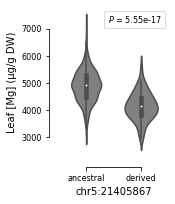

In [59]:
boxprops = {'edgecolor': 'black', 'linewidth': 0.5, 'facecolor': 'grey'}
lineprops = {'color': 'k', 'linewidth': 0.5}
boxplot_kwargs = dict({'boxprops': boxprops, 'medianprops': lineprops,
                       'whiskerprops': lineprops, 'capprops': lineprops,
                       'width': 0.6})

alt=df[df['chr5_21405867'] == '1']
ref=df[df['chr5_21405867'] == '0']
print('alt: ' + str(alt.shape[0]) + '\nref: ' + str(ref.shape[0]))

Order=[]
if alt.shape[0] > ref.shape[0]:
    Order=['1','0']
elif alt.shape[0] < ref.shape[0]:
    Order=['0','1']
print(Order)

@ticker.FuncFormatter
def major_formatter(x, pos):
    y = x /1000000
    return "%.0f" % y
cm = 1/2.54
plt.figure(figsize=(5*cm,7*cm))
ax=sns.violinplot(x='chr5_21405867', 
            y='Mg_blues',
            color='grey',
            data=df,
            order=Order,
            linewidth=1.5,
            fliersize=0,
            **boxplot_kwargs)
r,p = mannwhitneyu(alt['Mg_blues'],ref['Mg_blues'])
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 2
labels=[]
labels.append(r"$P$ = {:.2e}".format(p))
plt.legend(handles, labels, loc='best', fontsize=8, 
      fancybox=True, framealpha=0.7, 
      handlelength=0, handletextpad=0)
ax.set_xlabel('chr5:21405867',fontsize=10)
ax.set_xticklabels(['ancestral', 'derived'])
plt.ylabel('Leaf [Mg] (µg/g DW)',fontsize=10)

sns.despine(trim=True,offset=10)
plt.tick_params(labelsize=8)
plt.savefig("fig3b.pdf", format="pdf",bbox_inches="tight")
plt.savefig("Fig3b.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)

In [38]:
df.sort_values(by='Mg_blues').tail(10)

,Accession_ID,Mg_blues,chr5_21392702,chr5_21405867,chr5_282011,Latitude,Longitude
474,9405,6150.089773,1,0,1,55.7491,13.3990
96,6021,6168.601138,1,0,0,56.0600,14.2900
624,9671,6243.926109,0,0,1,46.3700,11.2800
263,7028,6300.326698,1,0,0,49.5166,9.3166
87,5984,6477.082911,1,0,1,49.4112,16.2815
471,9399,6492.298086,0,0,0,55.4234,13.9905
480,9421,6617.198369,1,0,0,55.9745,14.3997
176,6203,6715.415284,1,0,0,55.7714,14.1208
195,6284,6879.390064,.,0,1,55.5796,14.3336
384,8241,7218.969589,1,0,1,55.9473,13.8210


In [39]:
df.sort_values(by='Mg_blues')

,Accession_ID,Mg_blues,chr5_21392702,chr5_21405867,chr5_282011,Latitude,Longitude
555,9574,2993.006562,0,1,1,38.6000,-2.7000
491,9476,3084.170198,0,0,1,55.5796,14.3336
767,9855,3129.336517,0,1,0,40.5700,-3.8900
502,9515,3165.071233,0,1,1,39.7200,-6.8900
212,6911,3169.712772,0,0,1,15.1111,-23.6167
...,...,...,...,...,...,...,...
471,9399,6492.298086,0,0,0,55.4234,13.9905
480,9421,6617.198369,1,0,0,55.9745,14.3997
176,6203,6715.415284,1,0,0,55.7714,14.1208
195,6284,6879.390064,.,0,1,55.5796,14.3336
